In [2]:
import time
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from dpn_discovery.smt import SatResult
from dpn_discovery.smt.z3_solver import Z3SMTSolver
from dpn_discovery.smt.cvc5_solver import CVC5SMTSolver
from dpn_discovery.smt.yices2_solver import Yices2SMTSolver

warnings.filterwarnings("ignore")

SOLVER_CLASSES = [Z3SMTSolver, CVC5SMTSolver, Yices2SMTSolver]
SOLVER_NAMES   = ["Z3", "CVC5", "Yices2"]
SOLVER_COLORS  = {"Z3": "#4C72B0", "CVC5": "#DD8452", "Yices2": "#55A868"}

print("Imports OK  ✓")
print("Solver classes:", [cls.__name__ for cls in SOLVER_CLASSES])

Imports OK  ✓
Solver classes: ['Z3SMTSolver', 'CVC5SMTSolver', 'Yices2SMTSolver']


## 2 · Solver Factory & Timing Utility

`timed_task(solver_cls, task_fn)` instantiates the solver, runs `task_fn(solver)`, and returns `(SatResult, elapsed_ms)`.  
All benchmark calls go through this helper so timing is consistent.

In [3]:
from typing import Callable
from dpn_discovery.smt.base import SMTSolver


def timed_task(
    solver_cls: type[SMTSolver],
    task_fn: Callable[[SMTSolver], SatResult],
) -> tuple[SatResult, float]:
    """Instantiate *solver_cls*, run *task_fn*, return (result, elapsed_ms).

    A fresh solver instance is created for every call so that any
    internal caching inside the solver backend cannot carry state
    between repetitions.
    """
    solver = solver_cls()
    t0 = time.perf_counter()
    result = task_fn(solver)
    elapsed_ms = (time.perf_counter() - t0) * 1_000
    return result, elapsed_ms


# Quick smoke-test
_solver = Z3SMTSolver()
print("timed_task utility ready  ✓")
print("Z3 solver instance:", _solver)

timed_task utility ready  ✓
Z3 solver instance: <dpn_discovery.smt.z3_solver.Z3SMTSolver object at 0x115a61160>


## 3 · Task 1 — Guard Candidate Verification

**Application origin:** `guard_synthesis._verify_guard`


$$
\text{SAT?} \quad \bigwedge_{d^+ \in \text{pos}} g(d^+) \;\wedge\; \bigwedge_{d^- \in \text{neg}} \neg g(d^-)
$$



In [4]:
def task_guard_verification(solver: SMTSolver) -> SatResult:
    """Verify that a candidate guard  (amount ≤ 5000) ∧ (income > 2000)
    correctly classifies positive and negative data samples.

    This mirrors guard_synthesis._verify_guard: substitute concrete values
    into the symbolic guard expression and check satisfiability once per
    candidate.
    """
    # ── Symbolic variables ────────────────────────────────────────────────
    amount = solver.Real("amount")
    income = solver.Real("income")

    # ── Candidate guard: (amount ≤ 5000) ∧ (income > 2000) ───────────────
    guard = solver.And(
        solver.LE(amount, solver.RealVal(5_000)),
        solver.GT(income, solver.RealVal(2_000)),
    )

    # ── Observed data samples ─────────────────────────────────────────────
    positive_samples = [               # guard must evaluate to True
        {"amount": 3_000, "income": 4_000},
        {"amount": 5_000, "income": 2_500},
        {"amount": 1_200, "income": 3_100},
        {"amount": 4_800, "income": 2_100},
        {"amount": 500,   "income": 9_999},
    ]
    negative_samples = [               # guard must evaluate to False
        {"amount": 8_000, "income": 3_000},
        {"amount": 4_000, "income": 1_500},
        {"amount": 6_000, "income": 5_000},
        {"amount": 3_000, "income": 500},
        {"amount": 10_000, "income": 10_000},
    ]

    # ── Build context ─────────────────────────────────────────────────────
    ctx = solver.create_context(timeout_ms=5_000)

    for s in positive_samples:
        grounded = solver.substitute(
            guard,
            (amount, solver.RealVal(s["amount"])),
            (income, solver.RealVal(s["income"])),
        )
        ctx.add(grounded)                        # guard(s) must be True

    for s in negative_samples:
        grounded = solver.substitute(
            guard,
            (amount, solver.RealVal(s["amount"])),
            (income, solver.RealVal(s["income"])),
        )
        ctx.add(solver.Not(grounded))            # guard(s) must be False

    return ctx.check()


# Smoke-test: expect SAT (the guard correctly classifies all samples)
for name, cls in zip(SOLVER_NAMES, SOLVER_CLASSES):
    result, ms = timed_task(cls, task_guard_verification)
    print(f"  {name:8s}  →  {result.name}  ({ms:.3f} ms)")

  Z3        →  SAT  (22.820 ms)
  CVC5      →  SAT  (12.943 ms)
  Yices2    →  SAT  (1.055 ms)


## 4 · Task 2 — Linear Postcondition Template Synthesis

**Application origin:** `postcondition_synthesis._synthesise_update_template`


$$
\text{SAT?} \quad \bigwedge_{(x_\text{in},\, x_\text{out}) \in \text{obs}} \; x_\text{out} = c_1 \cdot x_\text{in} + c_2
$$


In [5]:
def task_template_synthesis(solver: SMTSolver) -> SatResult:
    """Synthesise constants c1, c2 such that  x_out = c1*x_in + c2
    holds for all observed (pre, post) value pairs.

    This mirrors postcondition_synthesis._synthesise_update_template:
    two symbolic Real variables (c1, c2) are constrained by equality
    assertions derived from observations, and the solver searches for
    a satisfying assignment.
    """
    # ── Unknowns the solver must find ─────────────────────────────────────
    c1 = solver.Real("c1")
    c2 = solver.Real("c2")

    # ── Observed (x_in, x_out) pairs — the linear relation is x' = 2x + 3 ─
    observations = [
        (1.0,  5.0),    # 2·1  + 3 = 5
        (2.0,  7.0),    # 2·2  + 3 = 7
        (3.0,  9.0),    # 2·3  + 3 = 9
        (4.0,  11.0),   # 2·4  + 3 = 11
        (5.0,  13.0),   # 2·5  + 3 = 13
        (10.0, 23.0),   # 2·10 + 3 = 23
        (0.0,  3.0),    # 2·0  + 3 = 3
        (7.5,  18.0),   # 2·7.5+ 3 = 18
    ]

    ctx = solver.create_context(timeout_ms=5_000)

    for x_in, x_out in observations:
        # x_out == c1 * x_in + c2
        lhs = solver.RealVal(x_out)
        rhs = solver.Add(
            solver.Mul(c1, solver.RealVal(x_in)),
            c2,
        )
        ctx.add(solver.Eq(lhs, rhs))

    return ctx.check()


# Smoke-test: expect SAT — unique solution c1=2, c2=3 exists
for name, cls in zip(SOLVER_NAMES, SOLVER_CLASSES):
    result, ms = timed_task(cls, task_template_synthesis)
    print(f"  {name:8s}  →  {result.name}  ({ms:.3f} ms)")

  Z3        →  SAT  (9.084 ms)
  CVC5      →  SAT  (1.418 ms)
  Yices2    →  SAT  (0.523 ms)


## 5 · Task 3 — Candidate Equivalence Under a Guard (UNSAT Check)

**Application origin:** `postcondition_synthesis._are_equivalent_under_guard`


$$
\text{UNSAT?} \quad g(V) \;\wedge\; e_1(V) \neq e_2(V)
$$



In [6]:
def task_equivalence_under_guard(solver: SMTSolver) -> SatResult:
    """Check whether two candidate update expressions are equivalent
    whenever the transition guard holds.

    Guard:   (amount ≤ 5000) ∧ (income > 2000)
    e1:      amount + 1000          (simple increment)
    e2:      amount + 1000          (identical — expects UNSAT)

    Formally checks:
        UNSAT?  guard(amount, income) ∧ e1(amount) ≠ e2(amount)

    An UNSAT result proves e1 ≡ e2 under the guard, so one is redundant.
    This mirrors postcondition_synthesis._are_equivalent_under_guard.
    """
    # ── Symbolic variables ────────────────────────────────────────────────
    amount = solver.Real("amount")
    income = solver.Real("income")

    # ── Guard: (amount ≤ 5000) ∧ (income > 2000) ─────────────────────────
    guard = solver.And(
        solver.LE(amount, solver.RealVal(5_000)),
        solver.GT(income, solver.RealVal(2_000)),
    )

    # ── Two candidate update expressions for the 'amount' variable ────────
    # e1 = amount + 1000
    e1 = solver.Add(amount, solver.RealVal(1_000))
    # e2 = amount + 1000  (same — should be detected as equivalent)
    e2 = solver.Add(amount, solver.RealVal(1_000))

    ctx = solver.create_context(timeout_ms=5_000)

    # Assert: guard holds AND the two expressions differ.
    # UNSAT → they are always equal under the guard → e2 is redundant.
    ctx.add(guard)
    ctx.add(solver.NEq(e1, e2))

    return ctx.check()   # UNSAT expected


# Smoke-test: expect UNSAT (the two expressions are identical)
for name, cls in zip(SOLVER_NAMES, SOLVER_CLASSES):
    result, ms = timed_task(cls, task_equivalence_under_guard)
    print(f"  {name:8s}  →  {result.name}  ({ms:.3f} ms)")

  Z3        →  UNSAT  (0.830 ms)
  CVC5      →  UNSAT  (1.123 ms)
  Yices2    →  UNSAT  (0.256 ms)


## 6 · Runtime Benchmarking Loop


In [7]:
N_REPETITIONS = 50

TASKS = {
    "Task 1\nGuard Verification":       task_guard_verification,
    "Task 2\nTemplate Synthesis":        task_template_synthesis,
    "Task 3\nEquivalence Pruning":       task_equivalence_under_guard,
}

records = []

for solver_name, solver_cls in zip(SOLVER_NAMES, SOLVER_CLASSES):
    for task_name, task_fn in TASKS.items():
        for run in range(N_REPETITIONS):
            result, elapsed_ms = timed_task(solver_cls, task_fn)
            records.append(
                {
                    "solver":   solver_name,
                    "task":     task_name,
                    "run":      run,
                    "time_ms":  elapsed_ms,
                    "result":   result.name,
                }
            )

df = pd.DataFrame(records)
print(f"Collected {len(df)} measurements  ({N_REPETITIONS} runs × "
      f"{len(SOLVER_NAMES)} solvers × {len(TASKS)} tasks)\n")

summary = (
    df.groupby(["solver", "task"])["time_ms"]
    .agg(mean_ms="mean", std_ms="std", min_ms="min", max_ms="max")
    .round(3)
)
print(summary.to_string())

Collected 450 measurements  (50 runs × 3 solvers × 3 tasks)

                                    mean_ms  std_ms  min_ms  max_ms
solver task                                                        
CVC5   Task 1\nGuard Verification     0.612   0.067   0.564   1.026
       Task 2\nTemplate Synthesis     0.678   0.082   0.602   0.994
       Task 3\nEquivalence Pruning    0.410   0.022   0.385   0.543
Yices2 Task 1\nGuard Verification     0.120   0.026   0.095   0.220
       Task 2\nTemplate Synthesis     0.133   0.074   0.089   0.500
       Task 3\nEquivalence Pruning    0.101   0.108   0.052   0.649
Z3     Task 1\nGuard Verification     0.601   0.117   0.544   1.343
       Task 2\nTemplate Synthesis     0.594   0.061   0.538   0.872
       Task 3\nEquivalence Pruning    0.235   0.020   0.208   0.292


## 7 · Visualization — Runtime Comparison per Task


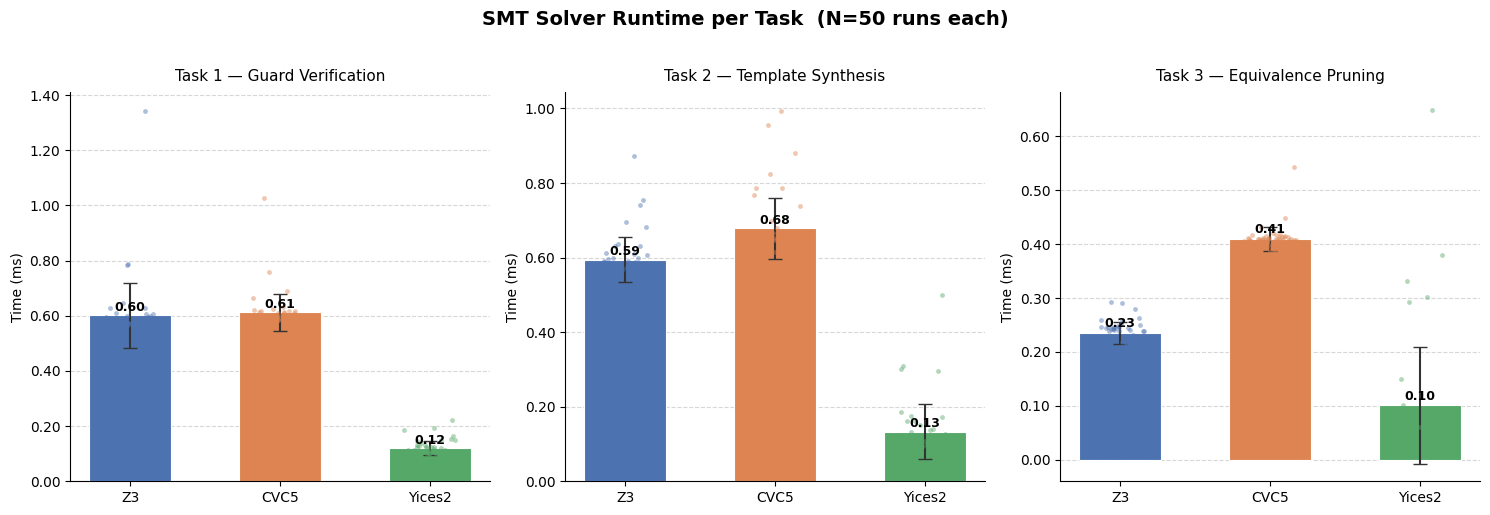

Figure saved → smt_benchmark_per_task.png


In [8]:
import numpy as np

task_names  = list(TASKS.keys())
n_tasks     = len(task_names)

fig, axes = plt.subplots(1, n_tasks, figsize=(5 * n_tasks, 5), sharey=False)
fig.suptitle("SMT Solver Runtime per Task  (N=50 runs each)", fontsize=14, fontweight="bold", y=1.02)

bar_width   = 0.55
rng         = np.random.default_rng(42)   # reproducible jitter

for ax, task in zip(axes, task_names):
    task_df = df[df["task"] == task]
    stats   = task_df.groupby("solver")["time_ms"].agg(["mean", "std"]).reindex(SOLVER_NAMES)

    x_pos = np.arange(len(SOLVER_NAMES))

    bars = ax.bar(
        x_pos,
        stats["mean"],
        yerr=stats["std"],
        width=bar_width,
        color=[SOLVER_COLORS[s] for s in SOLVER_NAMES],
        edgecolor="white",
        linewidth=0.8,
        error_kw={"elinewidth": 1.5, "capsize": 5, "ecolor": "#333333"},
        zorder=2,
    )

    # Jittered scatter of individual runs
    for i, solver in enumerate(SOLVER_NAMES):
        y_vals   = task_df[task_df["solver"] == solver]["time_ms"].values
        x_jitter = rng.uniform(-0.18, 0.18, size=len(y_vals))
        ax.scatter(
            i + x_jitter, y_vals,
            s=12, alpha=0.45, color=SOLVER_COLORS[solver],
            zorder=3, linewidths=0,
        )

    # Annotate bar tops with mean value
    for bar, mean_val in zip(bars, stats["mean"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + stats["std"].max() * 0.05,
            f"{mean_val:.2f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold",
        )

    short_title = task.replace("\n", " — ")
    ax.set_title(short_title, fontsize=11, pad=8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(SOLVER_NAMES, fontsize=10)
    ax.set_ylabel("Time (ms)", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("smt_benchmark_per_task.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → smt_benchmark_per_task.png")

## 8 · Visualization — Solver Ranking Heatmap


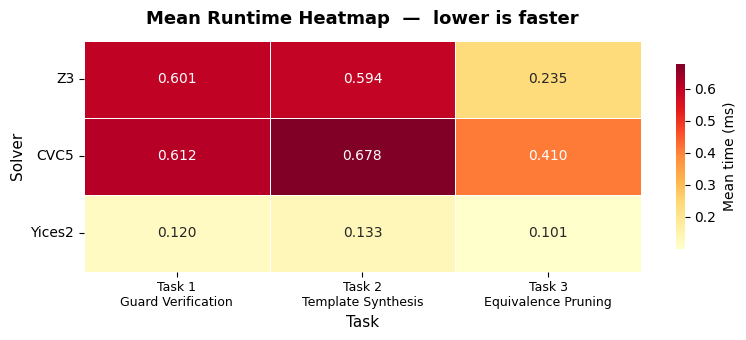

Figure saved → smt_benchmark_heatmap.png


In [9]:
# ── Pivot to solver × task mean-runtime matrix ────────────────────────────
pivot = (
    df.groupby(["solver", "task"])["time_ms"]
    .mean()
    .unstack("task")               # columns = tasks
    .reindex(index=SOLVER_NAMES, columns=task_names)
    .round(3)
)

# Short column labels for the heatmap
short_labels = [t.replace("\n", "\n") for t in task_names]

fig, ax = plt.subplots(figsize=(8, 3.5))

sns.heatmap(
    pivot,
    ax=ax,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Mean time (ms)", "shrink": 0.8},
    xticklabels=short_labels,
    yticklabels=SOLVER_NAMES,
)

ax.set_title("Mean Runtime Heatmap  —  lower is faster", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Task", fontsize=11)
ax.set_ylabel("Solver", fontsize=11)
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=10, rotation=0)

plt.tight_layout()
plt.savefig("smt_benchmark_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → smt_benchmark_heatmap.png")

## 9 · Visualization 

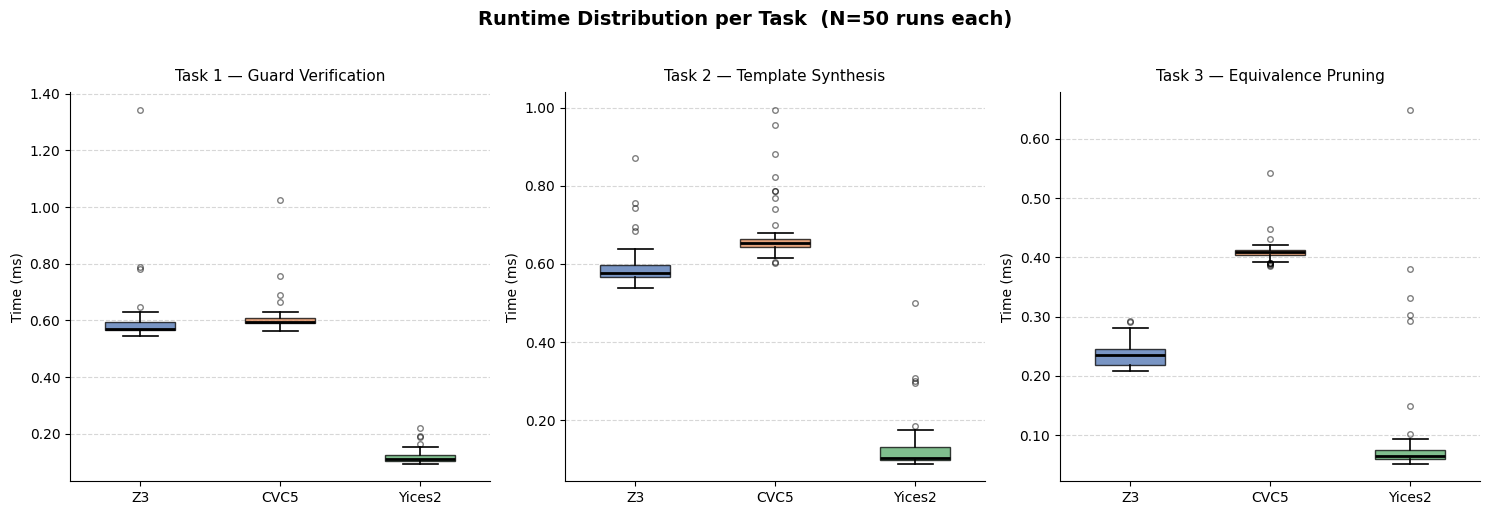

Figure saved → smt_benchmark_boxplot.png


In [10]:
fig, axes = plt.subplots(1, n_tasks, figsize=(5 * n_tasks, 5), sharey=False)
fig.suptitle("Runtime Distribution per Task  (N=50 runs each)", fontsize=14, fontweight="bold", y=1.02)

for ax, task in zip(axes, task_names):
    task_df = df[df["task"] == task]

    data_by_solver = [task_df[task_df["solver"] == s]["time_ms"].values for s in SOLVER_NAMES]

    bp = ax.boxplot(
        data_by_solver,
        patch_artist=True,
        notch=False,
        widths=0.5,
        medianprops={"color": "black", "linewidth": 2},
        whiskerprops={"linewidth": 1.2},
        capprops={"linewidth": 1.2},
        flierprops={"marker": "o", "markersize": 4, "alpha": 0.5},
    )

    for patch, solver in zip(bp["boxes"], SOLVER_NAMES):
        patch.set_facecolor(SOLVER_COLORS[solver])
        patch.set_alpha(0.75)

    short_title = task.replace("\n", " — ")
    ax.set_title(short_title, fontsize=11, pad=8)
    ax.set_xticks(range(1, len(SOLVER_NAMES) + 1))
    ax.set_xticklabels(SOLVER_NAMES, fontsize=10)
    ax.set_ylabel("Time (ms)", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("smt_benchmark_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → smt_benchmark_boxplot.png")

## 10 · Summary — Winner per Task & Overall Ranking

In [11]:
print("=" * 60)
print("  WINNER PER TASK  (fastest mean runtime)")
print("=" * 60)

for task in task_names:
    task_means = df[df["task"] == task].groupby("solver")["time_ms"].mean()
    winner     = task_means.idxmin()
    short      = task.replace("\n", " — ")
    print(f"  {short:<35s}  →  {winner}  ({task_means[winner]:.3f} ms)")

print()
print("=" * 60)
print("  OVERALL RANKING  (sum of mean runtimes across all tasks)")
print("=" * 60)

overall = df.groupby("solver")["time_ms"].mean().sort_values()
for rank, (solver, mean_ms) in enumerate(overall.items(), start=1):
    marker = "🏆" if rank == 1 else f"#{rank}"
    print(f"  {marker}  {solver:<10s}  avg {mean_ms:.3f} ms / check")

print()
print("Full pivot (mean ms):")
print(pivot.to_string())

  WINNER PER TASK  (fastest mean runtime)
  Task 1 — Guard Verification          →  Yices2  (0.120 ms)
  Task 2 — Template Synthesis          →  Yices2  (0.133 ms)
  Task 3 — Equivalence Pruning         →  Yices2  (0.101 ms)

  OVERALL RANKING  (sum of mean runtimes across all tasks)
  🏆  Yices2      avg 0.118 ms / check
  #2  Z3          avg 0.477 ms / check
  #3  CVC5        avg 0.567 ms / check

Full pivot (mean ms):
task    Task 1\nGuard Verification  Task 2\nTemplate Synthesis  Task 3\nEquivalence Pruning
solver                                                                                     
Z3                           0.601                       0.594                        0.235
CVC5                         0.612                       0.678                        0.410
Yices2                       0.120                       0.133                        0.101


## 11 · Scaling Behaviour — Runtime vs. Problem Complexity

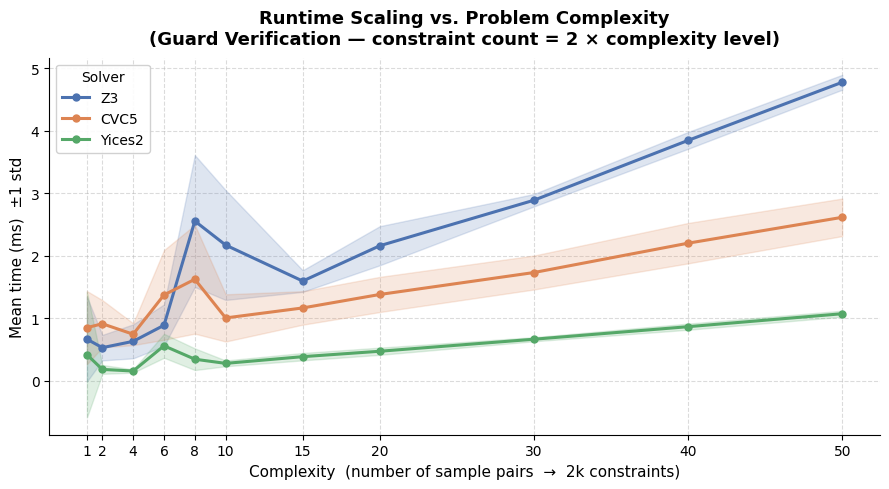

Figure saved → smt_benchmark_scaling.png


In [12]:
import random

# ── Complexity levels: number of (positive, negative) sample pairs ────────
COMPLEXITY_LEVELS = [1, 2, 4, 6, 8, 10, 15, 20, 30, 40, 50]
N_SCALE_REPS = 10   # repetitions per (solver, complexity) point

rng_scale = random.Random(0)   # reproducible synthetic data


def _make_scaling_task(n_pairs: int):
    """Return a task function that verifies a guard against n_pairs
    positive AND n_pairs negative samples (2*n_pairs constraints total).

    Guard: (x ≤ 5000) ∧ (y > 2000)
    Positive samples satisfy the guard; negative samples violate it.
    """
    # Pre-generate concrete sample values so they're identical across solvers
    pos = [{"x": rng_scale.uniform(0, 5000),   "y": rng_scale.uniform(2001, 9999)}
           for _ in range(n_pairs)]
    neg = [{"x": rng_scale.uniform(5001, 9999), "y": rng_scale.uniform(0, 1999)}
           for _ in range(n_pairs)]

    def task(solver: SMTSolver) -> SatResult:
        x = solver.Real("x")
        y = solver.Real("y")
        guard = solver.And(
            solver.LE(x, solver.RealVal(5_000)),
            solver.GT(y, solver.RealVal(2_000)),
        )
        ctx = solver.create_context(timeout_ms=10_000)
        for s in pos:
            grounded = solver.substitute(
                guard,
                (x, solver.RealVal(s["x"])),
                (y, solver.RealVal(s["y"])),
            )
            ctx.add(grounded)
        for s in neg:
            grounded = solver.substitute(
                guard,
                (x, solver.RealVal(s["x"])),
                (y, solver.RealVal(s["y"])),
            )
            ctx.add(solver.Not(grounded))
        return ctx.check()

    return task


# ── Collect measurements ──────────────────────────────────────────────────
scale_records = []

for k in COMPLEXITY_LEVELS:
    task_fn = _make_scaling_task(k)          # same samples for all solvers
    for solver_name, solver_cls in zip(SOLVER_NAMES, SOLVER_CLASSES):
        for rep in range(N_SCALE_REPS):
            _, elapsed_ms = timed_task(solver_cls, task_fn)
            scale_records.append(
                {"solver": solver_name, "complexity": k, "time_ms": elapsed_ms}
            )

scale_df = pd.DataFrame(scale_records)

# ── Aggregate mean ± std per (solver, complexity) ─────────────────────────
scale_agg = (
    scale_df.groupby(["solver", "complexity"])["time_ms"]
    .agg(mean="mean", std="std")
    .reset_index()
)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

for solver_name in SOLVER_NAMES:
    sub = scale_agg[scale_agg["solver"] == solver_name].sort_values("complexity")
    color = SOLVER_COLORS[solver_name]

    ax.plot(
        sub["complexity"], sub["mean"],
        marker="o", markersize=5,
        linewidth=2.2, color=color, label=solver_name,
    )
    ax.fill_between(
        sub["complexity"],
        sub["mean"] - sub["std"],
        sub["mean"] + sub["std"],
        alpha=0.18, color=color,
    )

ax.set_title(
    "Runtime Scaling vs. Problem Complexity\n"
    "(Guard Verification — constraint count = 2 × complexity level)",
    fontsize=13, fontweight="bold", pad=10,
)
ax.set_xlabel("Complexity  (number of sample pairs  →  2k constraints)", fontsize=11)
ax.set_ylabel("Mean time (ms)  ±1 std", fontsize=11)
ax.legend(title="Solver", fontsize=10, title_fontsize=10, framealpha=0.9)
ax.set_xticks(COMPLEXITY_LEVELS)
ax.grid(axis="both", linestyle="--", alpha=0.45)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("smt_benchmark_scaling.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → smt_benchmark_scaling.png")